# Function definitions

In [1]:
"""Notebook-friendly source-Parquet versus converted-LMDB inspection."""

from __future__ import annotations

import warnings
from pathlib import Path
from typing import Any

import duckdb
import lmdb
import msgpack
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

_LMDB_FORMAT = "rcs.lmdb_joint.v1"
_NDARRAY_TAG = "__ndarray__"


def _decode_lmdb_object(value: dict[str, Any]) -> Any:
    """Reconstruct arrays encoded by ``LMDBFrameWriter``."""
    if value.get(_NDARRAY_TAG) is not True:
        return value

    return np.frombuffer(value["data"], dtype=np.dtype(value["dtype"])).reshape(tuple(value["shape"])).copy()


def _unpack_lmdb_record(raw: bytes | None, *, key: bytes) -> dict[str, Any]:
    if raw is None:
        message = f"LMDB key is missing: {key!r}"
        raise KeyError(message)
    return msgpack.unpackb(raw, raw=False, object_hook=_decode_lmdb_object)


def _load_lmdb_episode(lmdb_path: str | Path, episode_index: int) -> tuple[dict[str, Any], pd.DataFrame]:
    """Load one episode from the single-file ``rcs.lmdb_joint.v1`` format."""
    lmdb_path = Path(lmdb_path).expanduser()
    if not lmdb_path.is_file():
        message = f"LMDB file does not exist: {lmdb_path}"
        raise FileNotFoundError(message)

    env = lmdb.open(
        str(lmdb_path),
        subdir=False,
        readonly=True,
        lock=False,
        readahead=False,
        max_readers=1,
    )
    try:
        with env.begin(buffers=False) as txn:
            meta = _unpack_lmdb_record(txn.get(b"meta"), key=b"meta")
            if meta.get("format") != _LMDB_FORMAT:
                message = f"Unsupported LMDB format {meta.get('format')!r}; expected {_LMDB_FORMAT!r}"
                raise ValueError(message)

            total_episodes = int(meta["total_episodes"])
            if not 0 <= episode_index < total_episodes:
                message = f"episode_index={episode_index} is outside the LMDB episode range 0:{total_episodes}"
                raise IndexError(message)

            global_start = int(meta["episode_from_indices"][episode_index])
            global_stop = int(meta["episode_to_indices"][episode_index])
            records = []
            for global_index in range(global_start, global_stop):
                key = f"frame/{global_index:09d}".encode("ascii")
                record = _unpack_lmdb_record(txn.get(key), key=key)
                if int(record["episode_index"]) != episode_index:
                    message = (
                        f"Frame {global_index} belongs to episode {record['episode_index']}, "
                        f"not requested episode {episode_index}"
                    )
                    raise ValueError(message)
                records.append(record)
    finally:
        env.close()

    frame_df = pd.DataFrame(
        {
            "timestamp": [float(record["timestamp"]) for record in records],
            "frame_index": [int(record["frame_index"]) for record in records],
            "index": [int(record["index"]) for record in records],
            "observation_state": [record["observation.state"] for record in records],
            "action": [record["action"] for record in records],
        }
    )
    return meta, frame_df


def inspect_lmdb_converted_episode(
    parquet_path: str | Path,
    lmdb_path: str | Path,
    episode_index: int = 0,
    start: int = 0,
    end: int = -1,
    joint_labels: dict[int, str] | None = None,
    *,
    drop_first: bool = False,
    show: bool = True,
) -> dict[str, Any]:
    """Compare one source-Parquet episode with its converted LMDB episode.

    Successful source UUIDs are ordered by UUID, matching the converter.
    The source action uses ``info.right.absolute_action`` and
    ``env_action.right.gripper`` because those are the fields consumed by the
    converter. Unlike the lagged ``action`` field, they are valid at step 0,
    so ``drop_first`` defaults to false.

    Layout:
      row 1: state comparison | action comparison
      row 2: all values combined
      row 3: Parquet obs/action | LMDB obs/action

    ``start`` is inclusive and ``end`` is exclusive. Set ``end=-1`` to use all
    aligned rows. If stationary-frame filtering was enabled during conversion,
    the LMDB can be shorter and row-wise comparison is not reliable; convert
    with ``--disable-stationary-frame-filtering`` for exact alignment.

    Returns the figure, axes, selected dataframes, metadata, UUID, and numeric
    error summary so the result can be inspected further in a notebook.
    """

    def as_matrix(series: pd.Series) -> np.ndarray:
        return np.vstack([np.asarray(value, dtype=np.float32).reshape(-1) for value in series.to_numpy()])

    parquet_path = Path(parquet_path).expanduser()
    parquet_source = str(parquet_path / "*.parquet") if parquet_path.is_dir() else str(parquet_path)

    con = duckdb.connect()
    try:
        parquet_uuids = con.execute(
            """
            SELECT DISTINCT uuid
            FROM read_parquet(?)
            WHERE success
            ORDER BY uuid
            """,
            [parquet_source],
        ).fetchnumpy()["uuid"]

        if not 0 <= episode_index < len(parquet_uuids):
            message = (
                f"episode_index={episode_index} is outside the available source episode "
                f"range 0:{len(parquet_uuids)}"
            )
            raise IndexError(message)
        uuid = str(parquet_uuids[episode_index])

        p_df = con.execute(
            """
            SELECT
                step,
                obs.right.gripper AS obs_gripper,
                env_action.right.gripper AS action_gripper,
                obs.right.joints AS obs_joints,
                info.right.absolute_action AS absolute_action
            FROM read_parquet(?)
            WHERE uuid = ?
            ORDER BY step
            """,
            [parquet_source, uuid],
        ).df()
    finally:
        con.close()

    meta, m_df = _load_lmdb_episode(lmdb_path, episode_index)
    if p_df.empty:
        message = f"No source rows found for UUID {uuid}"
        raise ValueError(message)
    if m_df.empty:
        message = f"No LMDB rows found for episode_index {episode_index}"
        raise ValueError(message)

    if drop_first:
        p_df = p_df.iloc[1:].reset_index(drop=True)
        m_df = m_df.iloc[1:].reset_index(drop=True)

    source_length = len(p_df)
    lmdb_length = len(m_df)
    if source_length != lmdb_length:
        warnings.warn(
            f"Source episode has {source_length} rows but LMDB episode has {lmdb_length}. "
            "The plots will compare their common prefix. This usually means stationary-frame "
            "filtering was enabled or a source row failed conversion.",
            stacklevel=2,
        )

    p_state = np.hstack([as_matrix(p_df["obs_joints"]), as_matrix(p_df["obs_gripper"])])
    p_action = np.hstack([as_matrix(p_df["absolute_action"]), as_matrix(p_df["action_gripper"])])
    m_state = as_matrix(m_df["observation_state"])
    m_action = as_matrix(m_df["action"])

    max_length = min(source_length, lmdb_length)
    stop = max_length if end == -1 else end
    if not 0 <= start < stop <= max_length:
        message = f"Use 0 <= start < end <= {max_length}; end=-1 means {max_length}."
        raise ValueError(message)

    p_state = p_state[start:stop]
    p_action = p_action[start:stop]
    m_state = m_state[start:stop]
    m_action = m_action[start:stop]

    p_x = p_df["step"].to_numpy()[start:stop]
    m_x = m_df["frame_index"].to_numpy()[start:stop]
    aligned_x = np.arange(start, stop)

    num_dims = min(p_state.shape[1], p_action.shape[1], m_state.shape[1], m_action.shape[1])
    if joint_labels is None:
        joint_labels = {
            0: "joint_1",
            1: "joint_2",
            2: "joint_3",
            3: "joint_4",
            4: "joint_5",
            5: "joint_6",
            6: "joint_7",
            7: "gripper",
        }

    colors = plt.cm.tab10(np.linspace(0, 1, num_dims, endpoint=False))
    fig = plt.figure(figsize=(16, 9), constrained_layout=True)
    grid = fig.add_gridspec(3, 2, height_ratios=[1, 1.1, 1])
    ax_state = fig.add_subplot(grid[0, 0])
    ax_action = fig.add_subplot(grid[0, 1])
    ax_combined = fig.add_subplot(grid[1, :])
    ax_parquet = fig.add_subplot(grid[2, 0])
    ax_lmdb = fig.add_subplot(grid[2, 1], sharey=ax_parquet)

    for dim in range(num_dims):
        name = joint_labels.get(dim, f"dim_{dim}")
        color = colors[dim]

        ax_state.plot(p_x, p_state[:, dim], color=color, linewidth=1.2, label=f"{name} — parquet")
        ax_state.plot(m_x, m_state[:, dim], color=color, linewidth=1.2, linestyle=":", label=f"{name} — LMDB")
        ax_action.plot(p_x, p_action[:, dim], color=color, linewidth=1.2, label=f"{name} — parquet")
        ax_action.plot(m_x, m_action[:, dim], color=color, linewidth=1.2, linestyle=":", label=f"{name} — LMDB")

        ax_combined.plot(aligned_x, p_state[:, dim], color=color, linewidth=1.2, label=f"{name} P obs")
        ax_combined.plot(aligned_x, p_action[:, dim], color=color, linewidth=1.2, linestyle=":", label=f"{name} P act")
        ax_combined.plot(aligned_x, m_state[:, dim], color=color, linewidth=1.0, alpha=0.5, label=f"{name} M obs")
        ax_combined.plot(
            aligned_x,
            m_action[:, dim],
            color=color,
            linewidth=1.0,
            linestyle=":",
            alpha=0.5,
            label=f"{name} M act",
        )

        ax_parquet.plot(aligned_x, p_state[:, dim], color=color, linewidth=1.2, label=f"{name} — obs")
        ax_parquet.plot(
            aligned_x, p_action[:, dim], color=color, linewidth=1.2, linestyle=":", label=f"{name} — action"
        )
        ax_lmdb.plot(aligned_x, m_state[:, dim], color=color, linewidth=1.2, label=f"{name} — obs")
        ax_lmdb.plot(aligned_x, m_action[:, dim], color=color, linewidth=1.2, linestyle=":", label=f"{name} — action")

    ax_state.set_title("State: Parquet vs LMDB", fontsize=10)
    ax_action.set_title("Action: Parquet vs LMDB", fontsize=10)
    ax_combined.set_title("All state and action values", fontsize=10)
    ax_parquet.set_title("Parquet: observation and action", fontsize=10)
    ax_lmdb.set_title("LMDB: observation and action", fontsize=10)

    for axis in (ax_state, ax_action):
        axis.set_xlabel("Source step / LMDB frame index", fontsize=8)
    for axis in (ax_combined, ax_parquet, ax_lmdb):
        axis.set_xlabel("Aligned valid-row index", fontsize=8)
    for axis in (ax_state, ax_action, ax_combined, ax_parquet, ax_lmdb):
        axis.grid(alpha=0.3)
        axis.tick_params(labelsize=7)

    ax_state.set_ylabel("State", fontsize=8)
    ax_action.set_ylabel("Action", fontsize=8)
    ax_combined.set_ylabel("Position / target", fontsize=8)
    ax_parquet.set_ylabel("Position / target", fontsize=8)
    ax_state.legend(ncol=2, fontsize=4.5)
    ax_action.legend(ncol=2, fontsize=4.5)
    ax_combined.legend(ncol=8, fontsize=4.2)
    ax_parquet.legend(ncol=2, fontsize=4.5)
    ax_lmdb.legend(ncol=2, fontsize=4.5)

    fig.suptitle(
        f"Episode {episode_index} — UUID {uuid} — aligned-row range {start}:{stop}",
        fontsize=13,
    )

    state_error = np.abs(p_state[:, :num_dims] - m_state[:, :num_dims])
    action_error = np.abs(p_action[:, :num_dims] - m_action[:, :num_dims])
    errors = {
        "state_max_abs": float(state_error.max()),
        "state_mean_abs": float(state_error.mean()),
        "action_max_abs": float(action_error.max()),
        "action_mean_abs": float(action_error.mean()),
    }
    print(
        f"source_rows={source_length}, lmdb_rows={lmdb_length}, compared={stop - start}; "
        f"state max/mean abs error={errors['state_max_abs']:.3g}/{errors['state_mean_abs']:.3g}; "
        f"action max/mean abs error={errors['action_max_abs']:.3g}/{errors['action_mean_abs']:.3g}"
    )

    if show:
        plt.show()

    axes = {
        "state": ax_state,
        "action": ax_action,
        "combined": ax_combined,
        "parquet": ax_parquet,
        "lmdb": ax_lmdb,
    }
    return {
        "figure": fig,
        "axes": axes,
        "uuid": uuid,
        "metadata": meta,
        "source": p_df,
        "lmdb": m_df,
        "errors": errors,
    }


__all__ = ["inspect_lmdb_converted_episode"]


source_rows=553, lmdb_rows=553, compared=553; state max/mean abs error=0.0293/0.00219; action max/mean abs error=0/0


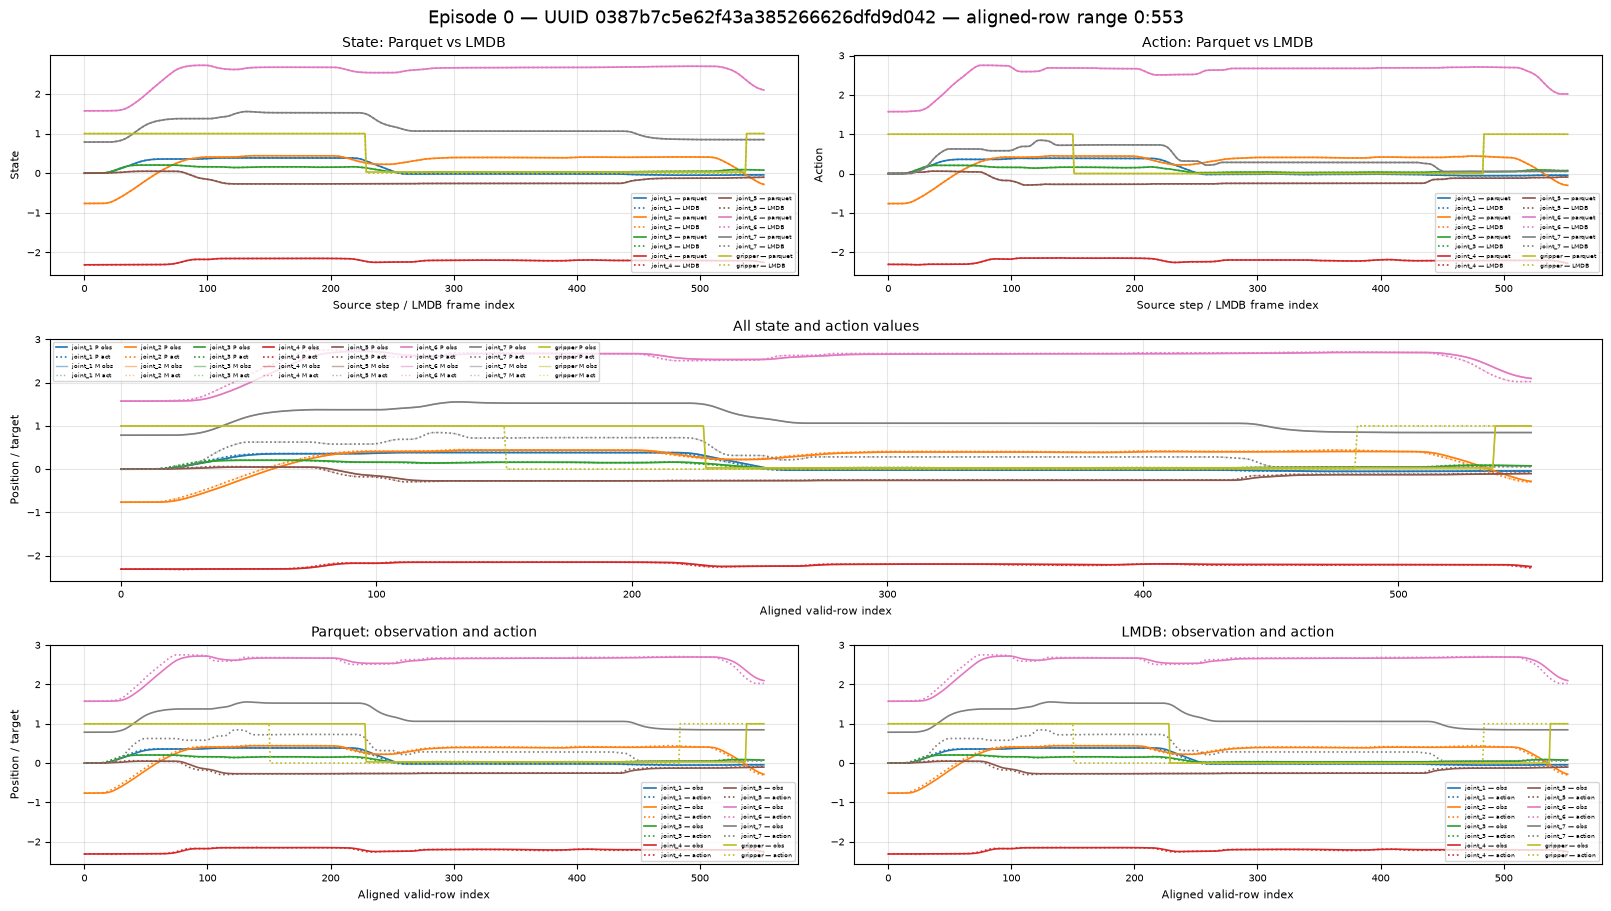

In [3]:
parquet_path = "/home/bien/Documents/Development/RCS/datasets/dataset_parquet/with_wood_cover/utn_fh_usbc_insertion"
lerobot_path = "/home/bien/Documents/Development/RCS/datasets/data_lmdb/utn_fh_usbc_insertion"

result = inspect_lmdb_converted_episode(parquet_path,lerobot_path,episode_index=0,start=0,end=-1)
